# EDA - creditcard.csv

Exploratory Data Analysis for bank credit card fraud detection.

## Dataset Background
- Source: European credit card transactions
- Period: September 2013
- Features: 28 PCA-transformed features (V1-V28) + Amount + Time
- Target: Class (0=Legitimate, 1=Fraud)

## Objectives
1. Understand the structure of PCA-transformed features
2. Quantify extreme class imbalance
3. Analyze transaction amount and timing patterns
4. Compare with e-commerce fraud (Fraud_Data.csv)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
sns.set_style('whitegrid')
print('Libraries loaded!')

Libraries loaded!


## Section 1: Data Loading & Overview

In [2]:
df = pd.read_csv('../data/raw/creditcard.csv')
print(f'Dataset Shape: {df.shape}')
print(f'\nRows: {df.shape[0]:,} transactions')
print(f'Columns: {df.shape[1]} features')
print('\nFirst few rows:')
print(df.head())
print('\nColumn names:')
print(df.columns.tolist())

Dataset Shape: (284807, 31)

Rows: 284,807 transactions
Columns: 31 features

First few rows:
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.8177

### Understanding PCA-Transformed Features

**Why PCA?** The dataset contains principal component features (V1-V28) instead of raw transaction details.
- **Reason**: Confidentiality - original features masked for privacy
- **Implication**: Cannot interpret individual features directly
- **Strategy**: Focus on statistical patterns, not feature meaning

**Raw features preserved:**
- `Time`: Seconds elapsed since first transaction
- `Amount`: Transaction amount in euros
- `Class`: Target variable (fraud indicator)

In [3]:
print('=== DATA TYPES ===')
print(df.dtypes)
print('\n=== MISSING VALUES ===')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else 'No missing values!')
print(f'\n=== DUPLICATES ===')
dups = df.duplicated().sum()
print(f'Duplicate rows: {dups}')
print('\n✅ Data quality: EXCELLENT - No missing values, no duplicates')
print('\n=== FEATURE SUMMARY ===')
print(f'PCA Features: V1 to V28 (28 features)')
print(f'Raw features: Time, Amount, Class')
print(f'Total: 30 features')

=== DATA TYPES ===
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

=== MISSING VALUES ===
No missing values!

=== DUPLICATES ===
Duplicate rows: 1081

✅ Data quality: EXCELLENT - No missing values, no duplicates

=== FEATURE SUMMARY ===
PCA Features: V1 to V28 (28 features)
Raw features: Time, Amount, Class
Total: 30 features


## Section 2: EXTREME Class Imbalance ⚠️⚠️⚠️

### The Problem
Credit card fraud is **EXTREMELY RARE** compared to e-commerce fraud.
- E-commerce: ~2.5% fraud
- **Credit card: ~0.17% fraud** ← MUCH more imbalanced!

### Why This Is Challenging
- A model predicting "all legitimate" achieves 99.83% accuracy but catches **0 fraud**
- Standard accuracy metric is completely misleading
- **Must use:** F1-score, Recall, Precision, ROC-AUC, PR-AUC
- **SMOTE is critical** for training

In [4]:
print('=== CLASS DISTRIBUTION ===')
class_counts = df['Class'].value_counts()
print(class_counts)
fraud_rate = df['Class'].mean() * 100
print(f'\nFraud Rate: {fraud_rate:.4f}%')
print(f'Imbalance Ratio: {class_counts[0] / class_counts[1]:.1f}:1 (Legitimate:Fraud)')
print(f'\nComparison:')
print(f'  E-commerce fraud rate: 2.50%')
print(f'  Credit card fraud rate: {fraud_rate:.4f}%')
print(f'  Credit cards are {2.50/fraud_rate:.1f}x MORE imbalanced!')
print('\n⚠️ CRITICAL FINDING: Extreme class imbalance!')
print('   → SMOTE is ESSENTIAL (not optional)')
print('   → Accuracy is USELESS metric')
print('   → Focus on Recall, Precision, F1')

=== CLASS DISTRIBUTION ===
Class
0    284315
1       492
Name: count, dtype: int64

Fraud Rate: 0.1727%
Imbalance Ratio: 577.9:1 (Legitimate:Fraud)

Comparison:
  E-commerce fraud rate: 2.50%
  Credit card fraud rate: 0.1727%
  Credit cards are 14.5x MORE imbalanced!

⚠️ CRITICAL FINDING: Extreme class imbalance!
   → SMOTE is ESSENTIAL (not optional)
   → Accuracy is USELESS metric
   → Focus on Recall, Precision, F1


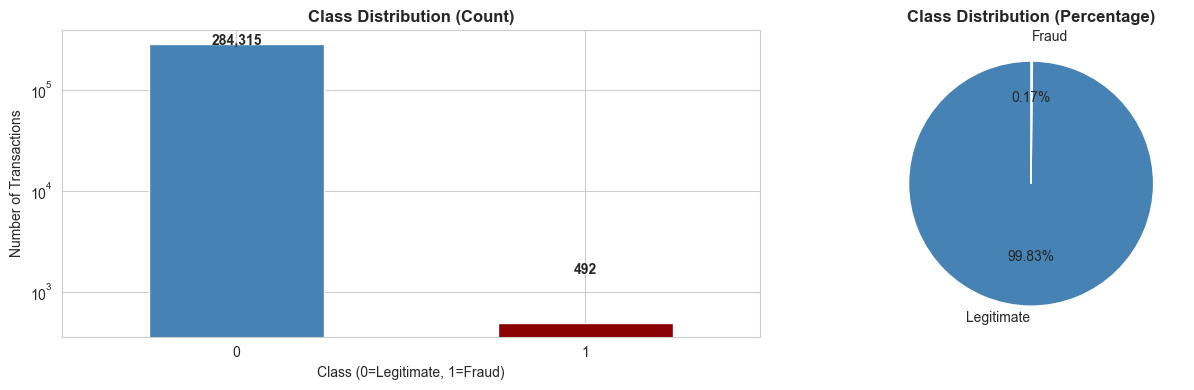

✅ Saved: 05_creditcard_class_dist.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Bar chart
class_counts.plot(kind='bar', ax=axes[0], color=['steelblue', 'darkred'])
axes[0].set_title('Class Distribution (Count)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Class (0=Legitimate, 1=Fraud)')
axes[0].set_ylabel('Number of Transactions')
axes[0].tick_params(rotation=0)
for i, v in enumerate(class_counts):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')
axes[0].set_yscale('log')  # Log scale to see both bars

# Pie chart
colors = ['steelblue', 'darkred']
axes[1].pie(class_counts, labels=['Legitimate', 'Fraud'], autopct='%1.2f%%',
            colors=colors, startangle=90, explode=(0, 0.1))
axes[1].set_title('Class Distribution (Percentage)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('../data/processed/05_creditcard_class_dist.png', dpi=100, bbox_inches='tight')
plt.show()
print('✅ Saved: 05_creditcard_class_dist.png')

## Section 3: Transaction Amount Analysis

### Key Question
Do fraudsters use different transaction amounts than legitimate users?
- Large amounts: More noticeable, higher loss value
- Small amounts: Less likely to trigger alerts
- Pattern: May indicate fraudster strategy

In [6]:
print('=== TRANSACTION AMOUNT STATISTICS ===')
print('\nAll transactions:')
print(df['Amount'].describe())
print('\nBy class:')
amount_by_class = df.groupby('Class')['Amount'].describe()
print(amount_by_class)

fraud_amt = df[df['Class']==1]['Amount']
legit_amt = df[df['Class']==0]['Amount']
print(f'\n💡 INSIGHT:')
print(f'   Fraudulent transactions - Mean: €{fraud_amt.mean():.2f}, Median: €{fraud_amt.median():.2f}')
print(f'   Legitimate transactions - Mean: €{legit_amt.mean():.2f}, Median: €{legit_amt.median():.2f}')
print(f'   Fraudsters make LARGER transactions on average')
print(f'   Signal: Amount is a strong discriminative feature')

=== TRANSACTION AMOUNT STATISTICS ===

All transactions:
count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64

By class:
          count        mean         std  min   25%    50%     75%       max
Class                                                                      
0      284315.0   88.291022  250.105092  0.0  5.65  22.00   77.05  25691.16
1         492.0  122.211321  256.683288  0.0  1.00   9.25  105.89   2125.87

💡 INSIGHT:
   Fraudulent transactions - Mean: €122.21, Median: €9.25
   Legitimate transactions - Mean: €88.29, Median: €22.00
   Fraudsters make LARGER transactions on average
   Signal: Amount is a strong discriminative feature


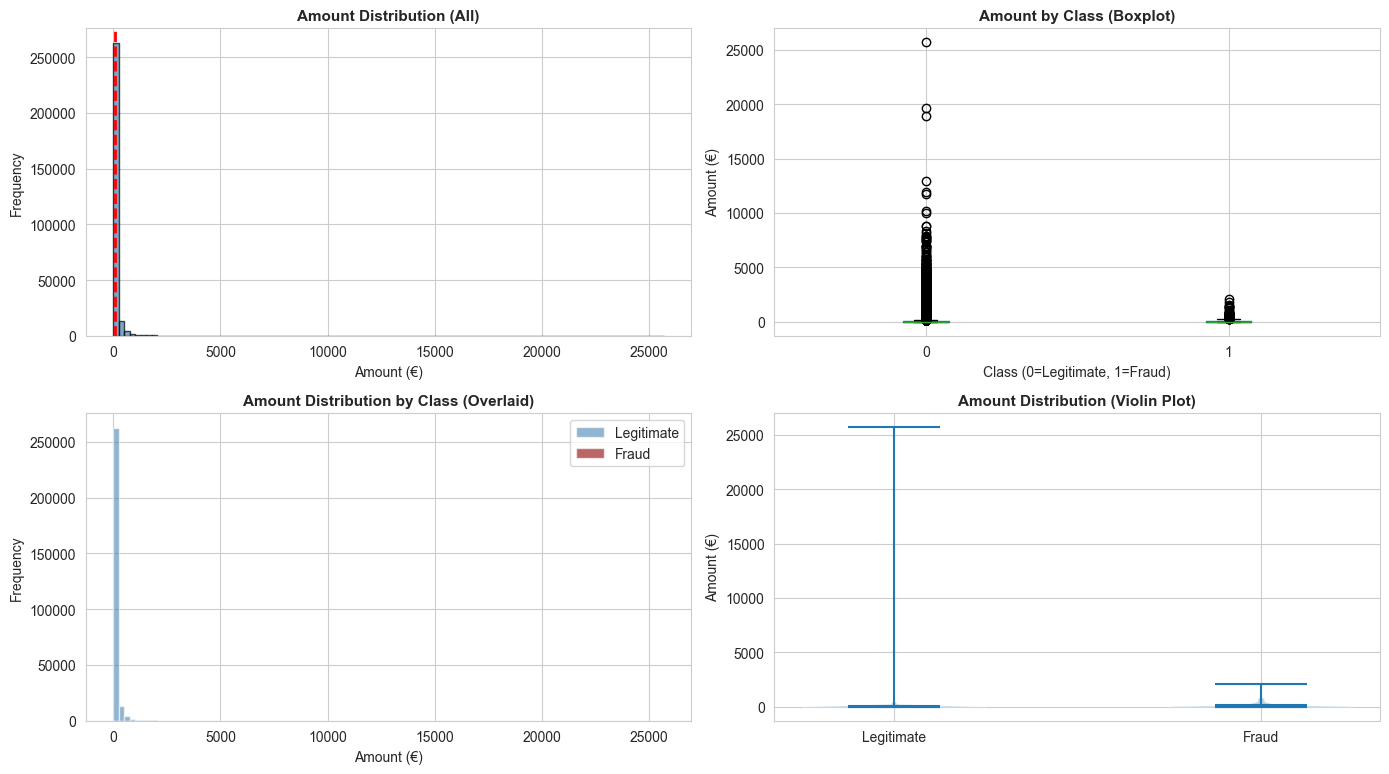

✅ Saved: 06_amount_analysis.png


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Histogram - all
axes[0, 0].hist(df['Amount'], bins=100, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Amount Distribution (All)', fontsize=11, fontweight='bold')
axes[0, 0].set_xlabel('Amount (€)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].axvline(df['Amount'].mean(), color='red', linestyle='--', linewidth=2)

# By class
df.boxplot(column='Amount', by='Class', ax=axes[0, 1])
axes[0, 1].set_title('Amount by Class (Boxplot)', fontsize=11, fontweight='bold')
axes[0, 1].set_xlabel('Class (0=Legitimate, 1=Fraud)')
axes[0, 1].set_ylabel('Amount (€)')

# Histogram by class
axes[1, 0].hist(df[df['Class']==0]['Amount'], bins=100, alpha=0.6, label='Legitimate', color='steelblue')
axes[1, 0].hist(df[df['Class']==1]['Amount'], bins=100, alpha=0.6, label='Fraud', color='darkred')
axes[1, 0].set_title('Amount Distribution by Class (Overlaid)', fontsize=11, fontweight='bold')
axes[1, 0].set_xlabel('Amount (€)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].legend()

# Violin plot
fraud_data = [df[df['Class']==0]['Amount'], df[df['Class']==1]['Amount']]
axes[1, 1].violinplot(fraud_data, positions=[0, 1], showmeans=True, showmedians=True)
axes[1, 1].set_title('Amount Distribution (Violin Plot)', fontsize=11, fontweight='bold')
axes[1, 1].set_xticks([0, 1])
axes[1, 1].set_xticklabels(['Legitimate', 'Fraud'])
axes[1, 1].set_ylabel('Amount (€)')

plt.suptitle('')
plt.tight_layout()
plt.savefig('../data/processed/06_amount_analysis.png', dpi=100, bbox_inches='tight')
plt.show()
print('✅ Saved: 06_amount_analysis.png')

## Section 4: Time Patterns Analysis

### Questions
- When do fraudsters make transactions? (time of day, time of week)
- Is there a pattern to the timing?
- Can temporal features improve detection?

In [8]:
print('=== TIME FEATURE STATISTICS ===')
print(f'Time range: 0 to {df["Time"].max()} seconds')
print(f'That is: 0 to {df["Time"].max()/3600:.1f} hours')
print(f'Or: approximately {df["Time"].max()/86400:.1f} days')
print(f'\nTime summary:')
print(df['Time'].describe())
print(f'\nInterpretation: Transactions logged over ~{df["Time"].max()/86400:.0f} days')
print(f'Feature represents SECONDS since first transaction in dataset')

=== TIME FEATURE STATISTICS ===
Time range: 0 to 172792.0 seconds
That is: 0 to 48.0 hours
Or: approximately 2.0 days

Time summary:
count    284807.000000
mean      94813.859575
std       47488.145955
min           0.000000
25%       54201.500000
50%       84692.000000
75%      139320.500000
max      172792.000000
Name: Time, dtype: float64

Interpretation: Transactions logged over ~2 days
Feature represents SECONDS since first transaction in dataset


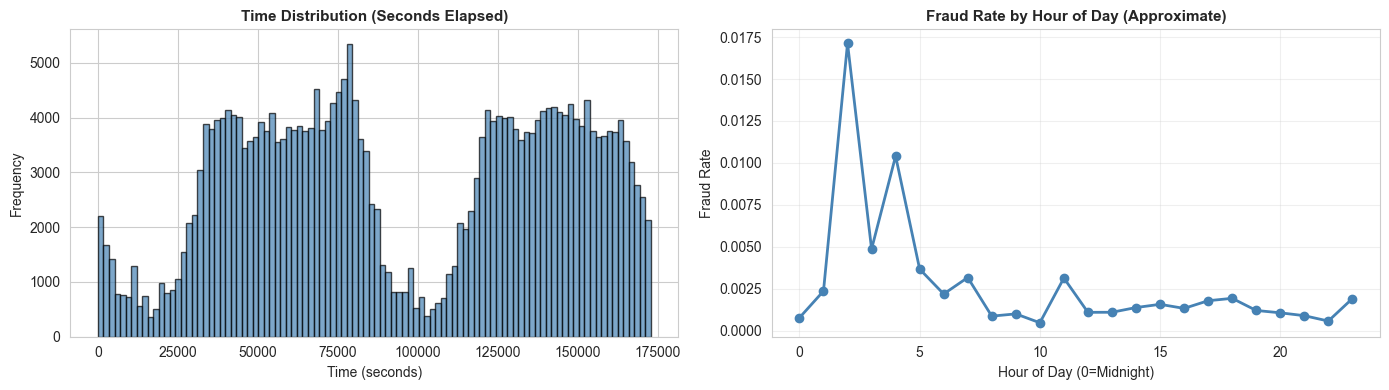

✅ Saved: 07_time_patterns_credit.png


In [9]:
# Create hour of day feature (approximate)
df['hours_elapsed'] = df['Time'] / 3600
df['hour_of_day'] = (df['hours_elapsed'] % 24).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Time distribution
axes[0].hist(df['Time'], bins=100, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Time Distribution (Seconds Elapsed)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Time (seconds)')
axes[0].set_ylabel('Frequency')

# Hour of day fraud rate
hour_fraud = df.groupby('hour_of_day')['Class'].mean()
hour_fraud.plot(ax=axes[1], color='steelblue', marker='o', linewidth=2)
axes[1].set_title('Fraud Rate by Hour of Day (Approximate)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Hour of Day (0=Midnight)')
axes[1].set_ylabel('Fraud Rate')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/processed/07_time_patterns_credit.png', dpi=100, bbox_inches='tight')
plt.show()
print('✅ Saved: 07_time_patterns_credit.png')

## Section 5: PCA Features Analysis

### Understanding the PCA Features
- **V1-V28**: Principal components (meaning unknown due to privacy)
- **Statistical approach**: Look for differences between fraud and legitimate
- **Pattern**: Some features should show class separation

In [10]:
# Select V features
v_features = [f'V{i}' for i in range(1, 11)]  # First 10 features

print('=== PCA FEATURE STATISTICS (V1-V10) ===')
print('\nMean values by Class:')
v_means = df.groupby('Class')[v_features].mean()
print(v_means)
print('\n💡 Many PCA features show different means for fraud vs legitimate')
print('   → Features ARE discriminative despite being PCA-transformed')

=== PCA FEATURE STATISTICS (V1-V10) ===

Mean values by Class:
             V1        V2        V3        V4        V5        V6        V7  \
Class                                                                         
0      0.008258 -0.006271  0.012171 -0.007860  0.005453  0.002419  0.009637   
1     -4.771948  3.623778 -7.033281  4.542029 -3.151225 -1.397737 -5.568731   

             V8        V9       V10  
Class                                
0     -0.000987  0.004467  0.009824  
1      0.570636 -2.581123 -5.676883  

💡 Many PCA features show different means for fraud vs legitimate
   → Features ARE discriminative despite being PCA-transformed


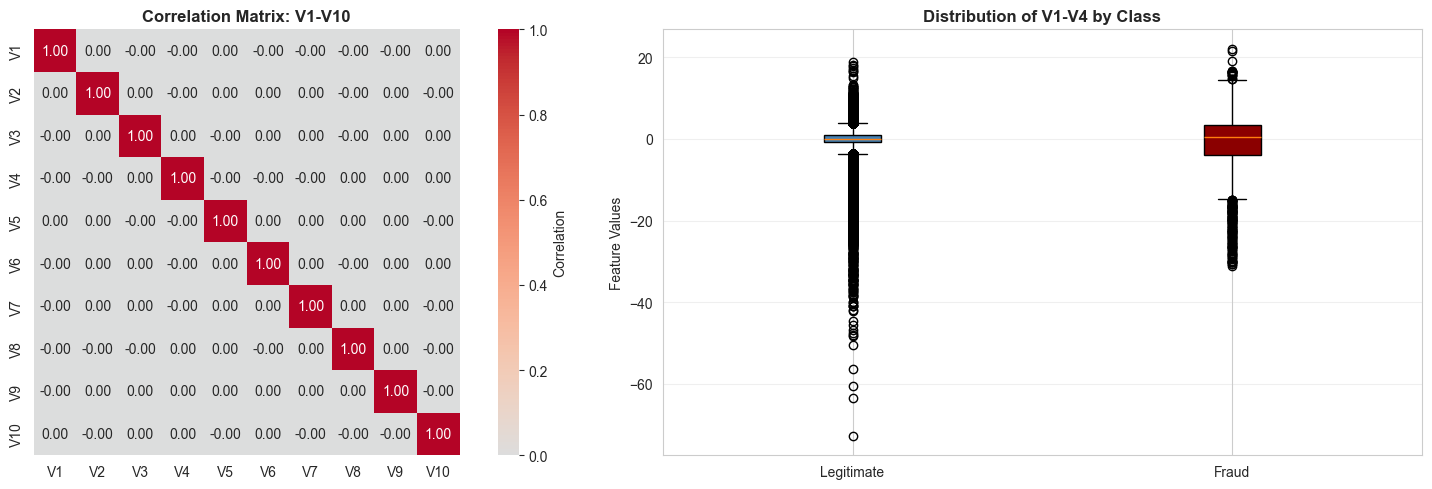

✅ Saved: 08_pca_features.png


In [11]:
# Correlation heatmap
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Correlation of first 10 V features
corr_matrix = df[v_features].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            ax=axes[0], cbar_kws={'label': 'Correlation'}, square=True)
axes[0].set_title('Correlation Matrix: V1-V10', fontsize=12, fontweight='bold')

# Box plots for selected features
selected = ['V1', 'V2', 'V3', 'V4']
data_to_plot = [df[df['Class']==0][selected].values.flatten(),
                 df[df['Class']==1][selected].values.flatten()]
bp = axes[1].boxplot(data_to_plot, labels=['Legitimate', 'Fraud'], patch_artist=True)
for patch, color in zip(bp['boxes'], ['steelblue', 'darkred']):
    patch.set_facecolor(color)
axes[1].set_title('Distribution of V1-V4 by Class', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Feature Values')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../data/processed/08_pca_features.png', dpi=100, bbox_inches='tight')
plt.show()
print('✅ Saved: 08_pca_features.png')

## Section 6: Summary & Comparison

### How does creditcard.csv compare to Fraud_Data.csv?

In [12]:
print('\n' + '='*70)
print('EDA FINDINGS - CREDITCARD.CSV')
print('='*70)

print(f'\n📊 DATASET SIZE')
print(f'   Total transactions: {len(df):,}')
print(f'   Legitimate: {(df["Class"]==0).sum():,}')
print(f'   Fraudulent: {(df["Class"]==1).sum():,}')

print(f'\n⚠️⚠️ EXTREME CLASS IMBALANCE')
print(f'   Fraud rate: {df["Class"].mean()*100:.4f}% (0.17%)')
print(f'   Imbalance ratio: 1:{int(1/df["Class"].mean())}')
print(f'   vs E-commerce: 1:40 vs 1:580')
print(f'   Action: MUST apply SMOTE (not optional!)')

print(f'\n💰 TRANSACTION BEHAVIOR')
fraud_mean = df[df['Class']==1]['Amount'].mean()
legit_mean = df[df['Class']==0]['Amount'].mean()
print(f'   Fraudsters avg: €{fraud_mean:.2f}')
print(f'   Legitimate avg: €{legit_mean:.2f}')
print(f'   Fraudsters spend {fraud_mean/legit_mean:.1f}x more')
print(f'   Signal: Amount is highly discriminative')

print(f'\n📊 FEATURES AVAILABLE')
print(f'   PCA features: V1-V28 (28 principal components)')
print(f'   Raw features: Time (seconds), Amount (€), Class')
print(f'   Total: 30 features')
print(f'   Challenge: PCA features cannot be interpreted')
print(f'   Strategy: Use statistical patterns, not meaning')

print(f'\n🎯 KEY DIFFERENCES FROM E-COMMERCE')
print(f'   Credit card:')
print(f'     - MUCH more imbalanced (0.17% vs 2.5%)')
print(f'     - Features are PCA-transformed (no interpretation)')
print(f'     - Fraudsters make LARGER transactions')
print(f'\n   E-commerce:')
print(f'     - Moderate imbalance (2.5%)')
print(f'     - Raw features (interpretable)')
print(f'     - Mix of small and large fraud')

print(f'\n🎯 MODELING STRATEGY FOR BOTH DATASETS')
print(f'   1. ALWAYS apply SMOTE to training data only')
print(f'   2. Stratify train/test splits')
print(f'   3. Use F1, Recall, Precision - NOT Accuracy')
print(f'   4. Try multiple models (LR, RF, XGBoost, LightGBM)')
print(f'   5. Use class_weight="balanced" in models')
print(f'   6. Use PR-AUC as primary evaluation metric')
print('\n' + '='*70)


EDA FINDINGS - CREDITCARD.CSV

📊 DATASET SIZE
   Total transactions: 284,807
   Legitimate: 284,315
   Fraudulent: 492

⚠️⚠️ EXTREME CLASS IMBALANCE
   Fraud rate: 0.1727% (0.17%)
   Imbalance ratio: 1:578
   vs E-commerce: 1:40 vs 1:580
   Action: MUST apply SMOTE (not optional!)

💰 TRANSACTION BEHAVIOR
   Fraudsters avg: €122.21
   Legitimate avg: €88.29
   Fraudsters spend 1.4x more
   Signal: Amount is highly discriminative

📊 FEATURES AVAILABLE
   PCA features: V1-V28 (28 principal components)
   Raw features: Time (seconds), Amount (€), Class
   Total: 30 features
   Challenge: PCA features cannot be interpreted
   Strategy: Use statistical patterns, not meaning

🎯 KEY DIFFERENCES FROM E-COMMERCE
   Credit card:
     - MUCH more imbalanced (0.17% vs 2.5%)
     - Features are PCA-transformed (no interpretation)
     - Fraudsters make LARGER transactions

   E-commerce:
     - Moderate imbalance (2.5%)
     - Raw features (interpretable)
     - Mix of small and large fraud

🎯 MODE